Индексы с NaN: [8, 38]


/tmp/ipykernel_3049/3891527531.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


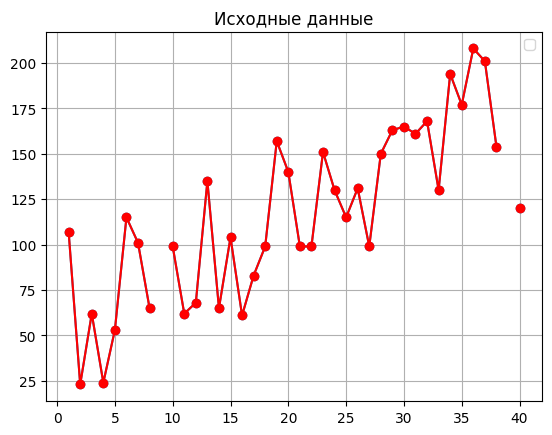

/tmp/ipykernel_3049/3891527531.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


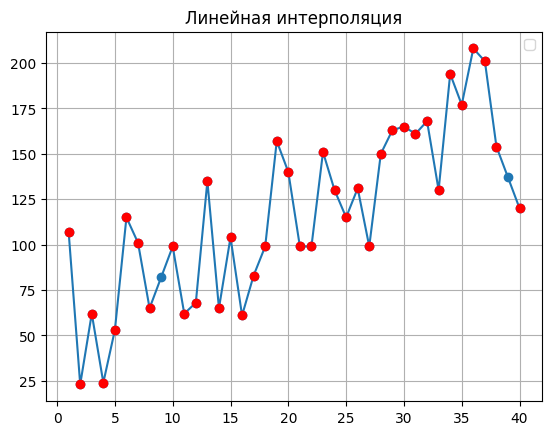

/tmp/ipykernel_3049/3891527531.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[107.0, 23.0, 62.0, 24.0, 53.0, 115.0, 101.0, 65.0, 82.0, 99.0, 62.0, 68.0, 135.0, 65.0, 104.0, 61.0, 83.0, 99.0, 157.0, 140.0, 99.0, 99.0, 151.0, 130.0, 115.0, 131.0, 99.0, 150.0, 163.0, 165.0, 161.0, 168.0, 130.0, 194.0, 177.0, 208.0, 201.0, 154.0, 137.0, 120.0]


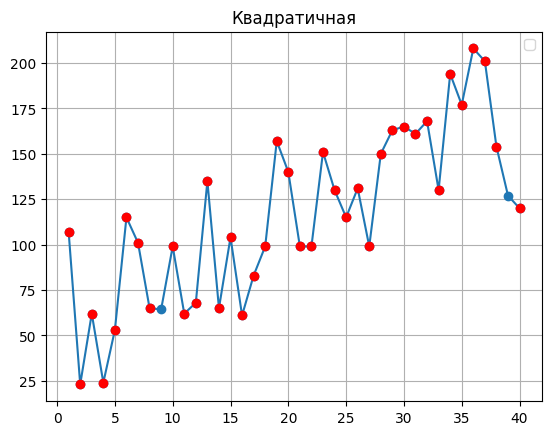

[107.0, 23.0, 62.0, 24.0, 53.0, 115.0, 101.0, 65.0, 64.33333333333334, 99.0, 62.0, 68.0, 135.0, 65.0, 104.0, 61.0, 83.0, 99.0, 157.0, 140.0, 99.0, 99.0, 151.0, 130.0, 115.0, 131.0, 99.0, 150.0, 163.0, 165.0, 161.0, 168.0, 130.0, 194.0, 177.0, 208.0, 201.0, 154.0, 127.0, 120.0]


In [52]:
import numpy as np
import matplotlib.pyplot as plt

with open('lab2_data.csv', 'r') as f:
  data = f.readlines()

x = []
y = []
nan_indices = []

for i in range(1, len(data)):
  row = data[i].strip().split(';')
  x.append(float(row[0]))
  if row[1] == 'NaN':
      y.append(float('nan'))
      nan_indices.append(i-1)
  else:
      y.append(float(row[1]))

print("Индексы с NaN:", nan_indices)

plt.plot(x, y, 'o-',)
plt.plot(x, y, 'ro-',)
plt.title('Исходные данные')
plt.legend()
plt.grid()
plt.show()

y_linear = y.copy()
y_quadratic = y.copy()

for idx in nan_indices:

  xk = idx - 1
  xk1 = idx + 1
  xk2 = idx - 2
  A = [x[xk], y[xk]]
  B = [x[xk1], y[xk1]]
  C = [x[xk2], y[xk2]]
  # print(A)
  # print(B)
  # print(C)
  # print(A[1])
  # print(B[1] - A[1])
  # print(B[0] - A[0])
  # print(A[1] + ((B[1] - A[1])/(B[0] - A[0])) * ((idx + 1) - A[0]))

  y_linear[idx] = (A[1] + ((B[1] - A[1])/(B[0] - A[0])) * ((idx + 1) - A[0]))

  y_quadratic[idx] = C[1] * (((idx + 1) - A[0]) * ((idx + 1) - B[0]))/(((C[0]) - A[0]) * ((C[0]) - B[0])) + A[1] * (((idx + 1) - C[0]) * ((idx + 1) - B[0]))/(((A[0]) - C[0]) * ((A[0]) - B[0])) + B[1] * (((idx + 1) - C[0]) * ((idx + 1) - A[0])) / (((B[0]) - C[0]) * ((B[0]) - A[0]))

plt.plot(x, y_linear, 'o-',)
plt.plot(x, y, 'ro',)
plt.title('Линейная интерполяция')
plt.legend()
plt.grid()
plt.show()
print(y_linear)

plt.plot(x, y_quadratic, 'o-',)
plt.plot(x, y, 'ro',)
plt.title('Квадратичная')
plt.legend()
plt.grid()
plt.show()
print(y_quadratic)